# Logistic Regression Practice Project

**Project Objective:** Build and evaluate a Logistic Regression model for binary classification.

## Import Required Libraries

Imports the libraries required for data analysis and logistic regression.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Load the Dataset

Loads the dataset into a Pandas DataFrame.

In [10]:
df = pd.read_csv("HR_comma_sep.csv")
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Explore the Dataset

Displays the structure and basic information of the dataset.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


## Data Preprocessing

Cleans and prepares the data for model training.

In [13]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


## Exploratory Data Analysis

Visualizes the dataset and feature relationships.

In [14]:
df.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

## Define Features and Target

Separates the independent variables and target variable.

In [16]:
df.left.value_counts()

left
0    11428
1     3571
Name: count, dtype: int64

## Split the Dataset

Splits the data into training and testing sets.

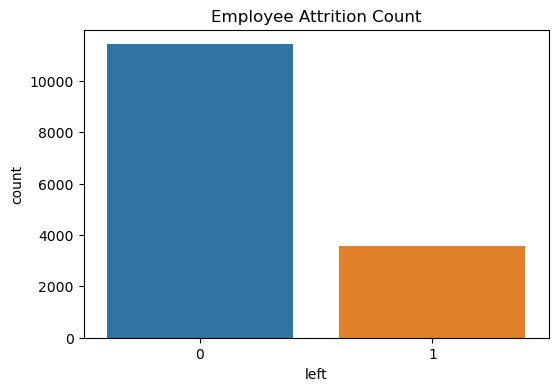

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x='left',data=df)
plt.title('Employee Attrition Count')
plt.show()

## Train the Logistic Regression Model

Builds the logistic regression model using the training data.

In [23]:
X=df[['satisfaction_level','average_montly_hours','promotion_last_5years']]
y=df['left']
X.head()

,satisfaction_level,average_montly_hours,promotion_last_5years
0,0.38,157,0
1,0.80,262,0
2,0.11,272,0
3,0.72,223,0
4,0.37,159,0


## Make Predictions

Predicts the target values using the trained model.

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=100)


## Evaluate the Model

Measures the model performance using evaluation metrics.

In [28]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

## Confusion Matrix

Displays the confusion matrix for classification performance.

In [29]:
y_predicted = model.predict(X_test)
y_predicted[:10]

array([0, 0, 0, 0, 1, 0, 0, 1, 0, 0], dtype=int64)

## Classification Report

Shows precision, recall, F1-score, and accuracy.

In [31]:
model.predict_proba(X_test[:5])

array([[0.85481208, 0.14518792],
       [0.93640469, 0.06359531],
       [0.63815986, 0.36184014],
       [0.85084497, 0.14915503],
       [0.40998294, 0.59001706]])

## Conclusion

Summarizes the overall findings of the project.

In [32]:
model.score(X_test,y_test)

0.774

In [33]:
model.coef_

array([[-3.66735239e+00,  2.44084007e-03, -1.52869237e+00]])

In [34]:
model.intercept_

array([0.40632218])

In [36]:
sample_employee = [[0.4,250,0]]
model.predict(sample_employee)

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0], dtype=int64)